<div class="alert alert-block alert-info" style="margin-top: 20px">

## 📘 On Labs and Eggs

### Table of contents
1. Introduction
2. Reading the data into R
3. Data inspection
4. Data visualisation.
5. Creating the model.
6. Model diagnostics
7. Statistics
8. But these extreme values
9. Simu

<div class="alert alert-block alert-info" style="margin-top: 20px">
    
## Labs

## 1. Introduction

Consistency between laboratory tests is important and yet the results may depend on who did the test and where the test was performed. In an experiment to test levels of consistency, a large jar of dried egg powder was divided up into a number of samples. Because the powder was homogenized, the fat content of the samples is the same, but this fact is withheld from the laboratories. Four samples were sent to each of six laboratories. Two of the samples were labelled as G and two as H, although in fact they were identical. The laboratories were instructed to give two samples to two different technicians. The technicians were then instructed to divide their samples into two parts and measure the fat content of each.

**So each laboratory reported eight measures, each technician four measures, that is, two replicated measures on each of two samples.**


A data frame with 48 observations on the following 4 variables.

* Fat: a numeric vector
* Lab: a factor with levels I II III IV V VI
* Technician :a factor with levels one two
* Sample: a factor with levels G H

Note that although the samples are identical they are labels H and G with a purpose, its allows us to see the sample also a random effect nested in technician.  




## 2. Reading the data into R

## Mixed Effects Model using the Eggs Dataset
### Step 1: Load Required Packages

In [12]:
# install.packages("faraway")
# install.packages("dplyr")
# install.packages("ggplot2")
# install.packages("lme4")
# install.packages("lmerTest")
# install.packages("car")
# install.packages("lattice")

In [14]:
# Load required packages
library(faraway)
library(dplyr)
library(ggplot2)
library(lme4)
library(lmerTest)
library(car)
library(lattice)

### Step 2: Load the Dataset

In [19]:
# Load the eggs dataset
data("eggs")

# View the entire dataset
eggs

# View(eggs)

,Fat,Lab,Technician,Sample
,<dbl>,<fct>,<fct>,<fct>
1,0.62,I,one,G
2,0.55,I,one,G
3,0.34,I,one,H
4,0.24,I,one,H
5,0.80,I,two,G
6,0.68,I,two,G
7,0.76,I,two,H
8,0.65,I,two,H
9,0.30,II,one,G


**Assignment:** Do the full analysis including data diagnostics and model diagnostics and interpretation of the results regarding the labs and technicians. Use the Word file of previous and this lecture, and the internet for help

## 3. Data Inspection

In [20]:
# Display structure of the dataset
str(eggs)

# Display summary statistics
summary(eggs)

'data.frame':	48 obs. of  4 variables:
 $ Fat       : num  0.62 0.55 0.34 0.24 0.8 0.68 0.76 0.65 0.3 0.4 ...
 $ Lab       : Factor w/ 6 levels "I","II","III",..: 1 1 1 1 1 1 1 1 2 2 ...
 $ Technician: Factor w/ 2 levels "one","two": 1 1 1 1 2 2 2 2 1 1 ...
 $ Sample    : Factor w/ 2 levels "G","H": 1 1 2 2 1 1 2 2 1 1 ...


      Fat          Lab    Technician Sample
 Min.   :0.0600   I  :8   one:24     G:24  
 1st Qu.:0.3075   II :8   two:24     H:24  
 Median :0.3700   III:8                    
 Mean   :0.3875   IV :8                    
 3rd Qu.:0.4300   V  :8                    
 Max.   :0.8000   VI :8                    

All factor and numerical values are read correctly. But are they nested or not

### Step 3: Check Whether Technician is Nested Within Lab

In [21]:
# Cross-tabulation of Lab, Technician and Sample
with(eggs, table(Lab, Technician, Sample))

, , Sample = G

     Technician
Lab   one two
  I     2   2
  II    2   2
  III   2   2
  IV    2   2
  V     2   2
  VI    2   2

, , Sample = H

     Technician
Lab   one two
  I     2   2
  II    2   2
  III   2   2
  IV    2   2
  V     2   2
  VI    2   2


The table helps determine whether technicians are nested within laboratories.

This looks like a factorial design all combinations from lab and and technician are measured but note that these technician are different persons in the different selected labs and that the two sample per technician are also randomly allocated

To see this we make a factor that codes the technician uniquely.

### Step 4: Create a Unique Technician Factor

Since technician numbers repeat across laboratories, create a unique identifier.

In [22]:
# Create a unique technician factor
eggs$Unique <- with(eggs,
                    factor(paste0(Lab, Technician)))        # factor(paste0(Lab, Technician)) pas the level names of lab and technician together

# Display the new factor
eggs$Unique

[1] Ione   Ione   Ione   Ione   Itwo   Itwo   Itwo   Itwo   IIone  IIone 
[11] IIone  IIone  IItwo  IItwo  IItwo  IItwo  IIIone IIIone IIIone IIIone
[21] IIItwo IIItwo IIItwo IIItwo IVone  IVone  IVone  IVone  IVtwo  IVtwo 
[31] IVtwo  IVtwo  Vone   Vone   Vone   Vone   Vtwo   Vtwo   Vtwo   Vtwo  
[41] VIone  VIone  VIone  VIone  VItwo  VItwo  VItwo  VItwo 
12 Levels: IIIone IIItwo IIone IItwo Ione Itwo IVone IVtwo VIone VItwo ... Vtwo

### Step 5: Verify the Nesting Structure

In [23]:
# Check the relationship between Lab and Unique Technician
with(eggs, table(Lab, Unique))

     Unique
Lab   IIIone IIItwo IIone IItwo Ione Itwo IVone IVtwo VIone VItwo Vone Vtwo
  I        0      0     0     0    4    4     0     0     0     0    0    0
  II       0      0     4     4    0    0     0     0     0     0    0    0
  III      4      4     0     0    0    0     0     0     0     0    0    0
  IV       0      0     0     0    0    0     4     4     0     0    0    0
  V        0      0     0     0    0    0     0     0     0     0    4    4
  VI       0      0     0     0    0    0     0     0     4     4    0    0

The zero’s are the level combinations that are not measured, The pattern of 4’s should be clear.

Lets us proceed with the summary

In [24]:
# Display summary statistics
summary(eggs)

      Fat          Lab    Technician Sample     Unique  
 Min.   :0.0600   I  :8   one:24     G:24   IIIone : 4  
 1st Qu.:0.3075   II :8   two:24     H:24   IIItwo : 4  
 Median :0.3700   III:8                     IIone  : 4  
 Mean   :0.3875   IV :8                     IItwo  : 4  
 3rd Qu.:0.4300   V  :8                     Ione   : 4  
 Max.   :0.8000   VI :8                     Itwo   : 4  
                                            (Other):24  

Let us look in more detail to the statistics per lab and technician. Here we use dplyr packages functions that helps us to organise our data; like in this case get summaries of factor levels of Lab and technicians.

eggs %>% group_by(Lab) %>% summarise(Mean = mean(Fat))) could be read as follow with the so-called pipe, %>%,

to be read as use the previous step in the next step:

Take egg data and apply the function group_by(Labs) on it and use that result to calculate the summaries per labs.

### Step 6: Mean Fat Content for Each Laboratory

In [25]:
library(dplyr)

# Mean fat content by laboratory
DiffM <- eggs %>% group_by(Lab) %>% summarise( Mean = mean(Fat))

DiffM

Lab,Mean
<fct>,<dbl>
I,0.58000
II,0.34000
III,0.40750
IV,0.37625
V,0.35375
VI,0.26750


### Step 7: Plot Laboratory Means

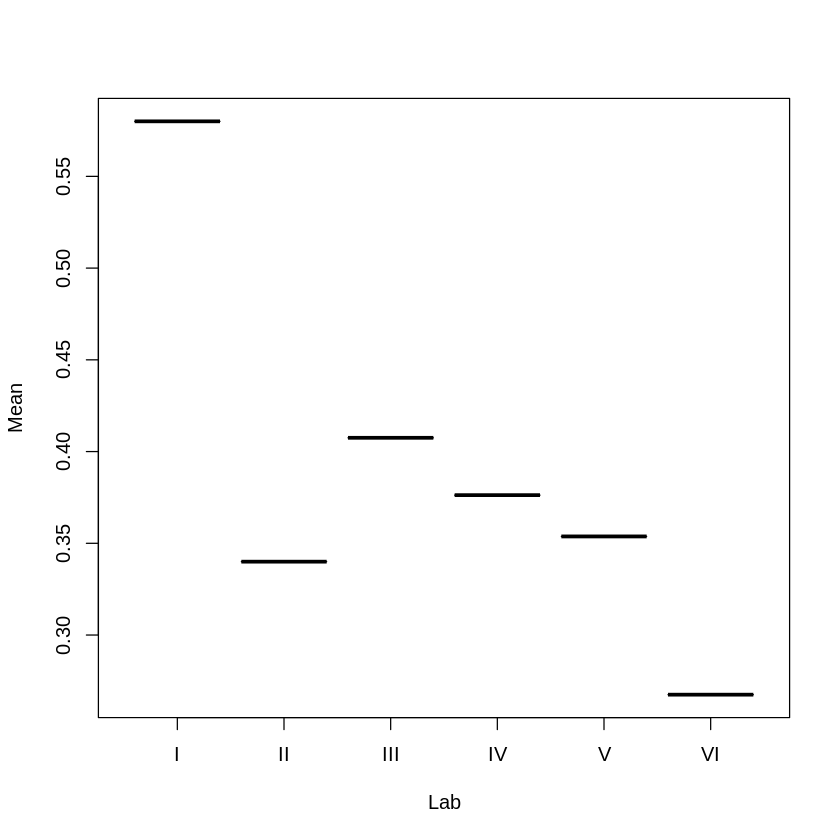

In [26]:
plot(DiffM)

We clearly observe different lab means and quite some variance. How much variance?

### Step 8: Variance of Laboratory Means

In [27]:
var(DiffM$Mean)

[1] 0.01107563

But what about the means per technician do they differ? Note this is the mean of two measurements

### Step 9: Mean Fat Content for Each Technician

In [28]:
# Mean fat content by technician
DiffMT <- eggs %>% group_by(Unique) %>% summarise( Mean = mean(Fat))

DiffMT

Unique,Mean
<fct>,<dbl>
IIIone,0.3700
IIItwo,0.4450
IIone,0.3650
IItwo,0.3150
Ione,0.4375
Itwo,0.7225
IVone,0.3750
IVtwo,0.3775
VIone,0.3600


### Step 10: Plot Technician Means

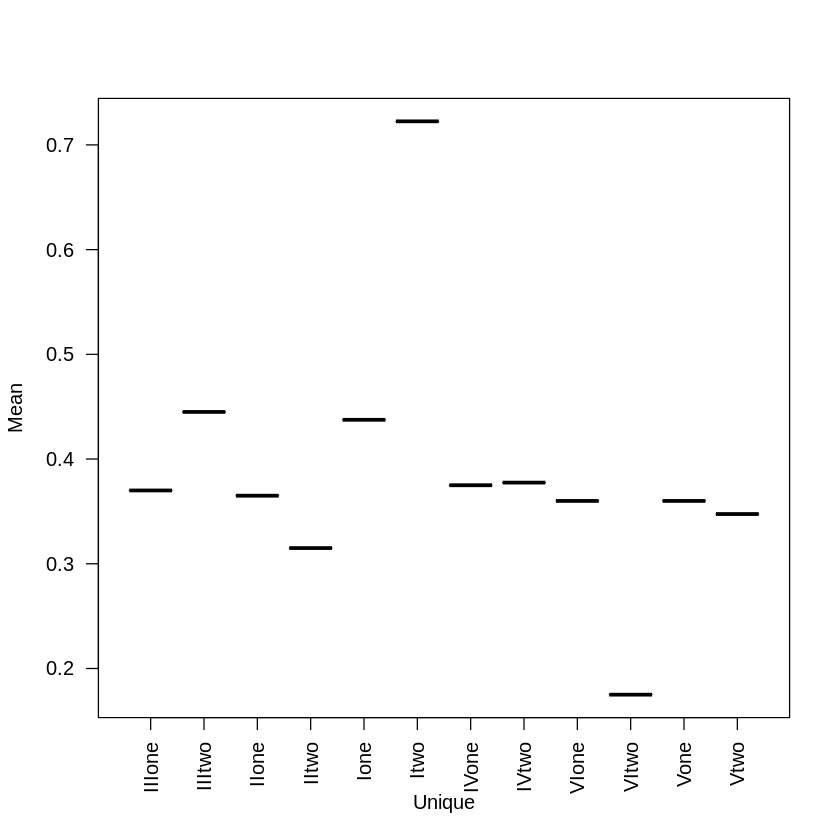

In [29]:
plot(DiffMT, las = 2)      # las = 2 Rotate x-axis labels

### Step 11: Variance Among Technician Means

In [30]:
var(DiffMT$Mean)

[1] 0.01569318

This is telling.Some technicians deviate further from the grand mean than other technicians.

We keep the information gathered above in our minds when we analyse the statistical outputs of our model.

## 4. Data Visualisation:
### Step 12: Scatter Plot by Laboratory

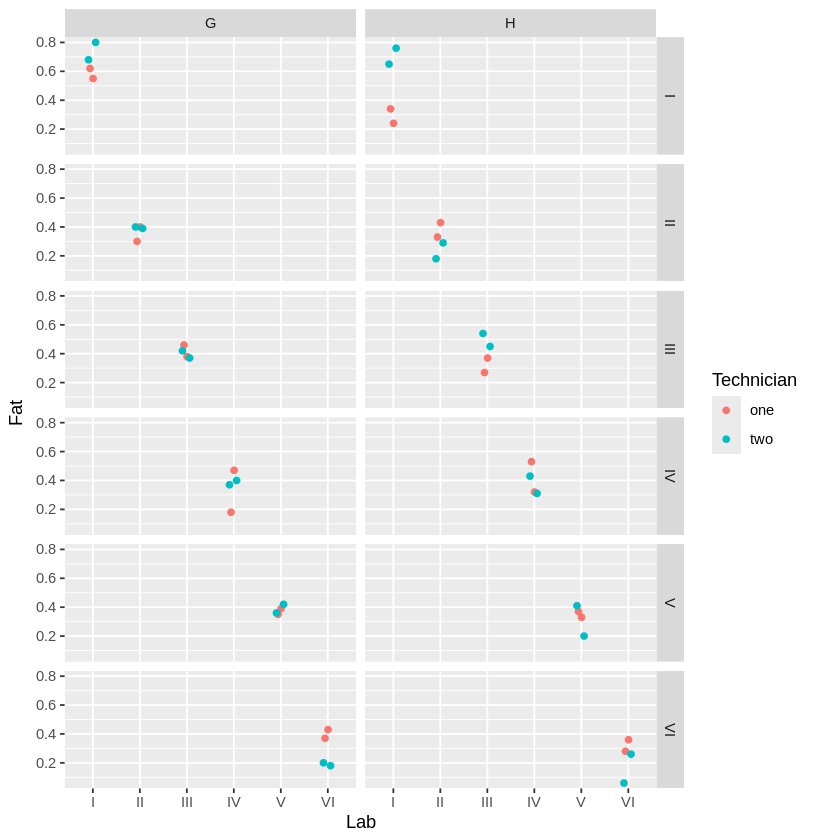

In [31]:
library(ggplot2)

ggplot(eggs, aes( x = Lab, y = Fat, color = Technician)) +
  geom_point(position = position_jitter( width = 0.1, height = 0)) +
  facet_grid(Lab ~ Sample)


To get another perspective we plot the data differently.

### Step 13: Alternative Visualization

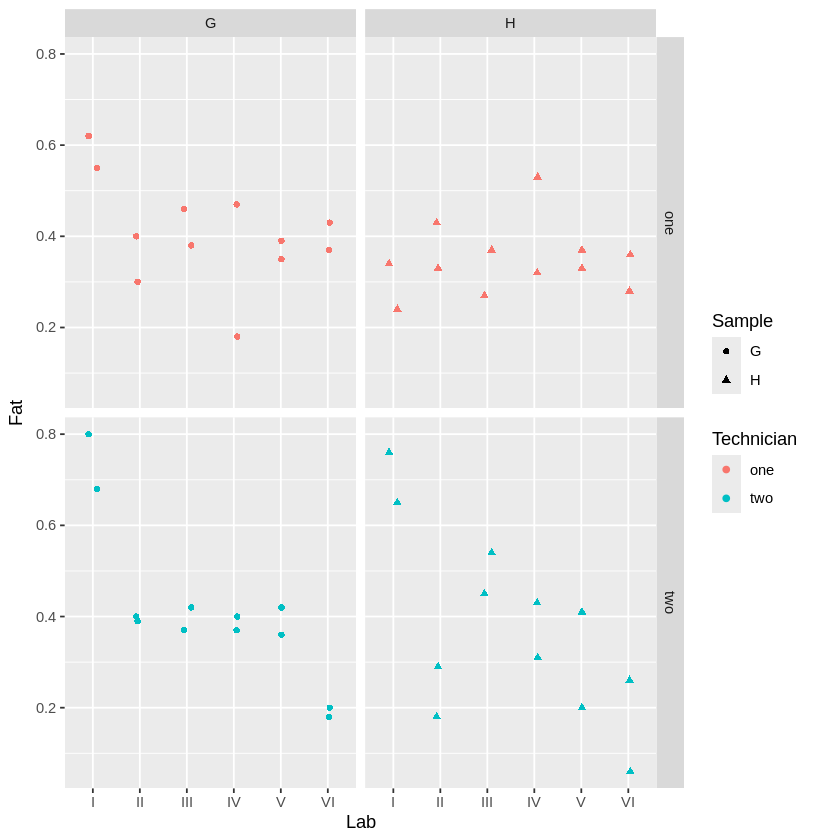

In [34]:
ggplot(eggs, aes(x = Lab, y = Fat, color = Technician, shape = Sample)) +
  geom_point(position = position_jitter(width = 0.1, height = 0)) +
  facet_grid(Technician ~ Sample)

The structure of the data is that any two technicians work in one lab location; the experimental unit are the labs with all its specific facilities. Lab we chosen randomly from a population of labs and within the labs two technician were selection from a population of technicians and the sample was analysed by the technician. The is case all the factors are random variables and there fore we do not have a mixed model but a random effect model.

## 5. Creating the Model:

Similar to the shorthand A*B notation also stand for A + B + A:B for the mixed models we have for mixed models the shorthand notation of (1|A/B/C) for standing for (1|A) + (1|A:B) + (1|A:B:C)

Note that there are two replications per technician, so sample is also a random effect that can be included.

### Step 14: Fit the Mixed Effects Model

The shorthand notation
$$
(1 \mid \text{Lab}/\text{Technician}/\text{Sample})
$$

is equivalent to

$$
(1 \mid \text{Lab})
+
(1 \mid \text{Lab}:\text{Technician})
+
(1 \mid \text{Lab}:\text{Technician}:\text{Sample})
$$

__Model using shorthand notation__

In [35]:
library(lme4)
library(lmerTest)

In [36]:
ModelZ <- lmer(Fat ~ 1 +
  (1 | Lab/Technician/Sample),
  data = eggs)

__Equivalent expanded model__

In [37]:
Model <- lmer(Fat ~ 1 +
  (1 | Lab) +
  (1 | Lab:Technician) +
  (1 | Lab:Technician:Sample),
  data = eggs)

summary(Model)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
Fat ~ 1 + (1 | Lab) + (1 | Lab:Technician) + (1 | Lab:Technician:Sample)
   Data: eggs

REML criterion at convergence: -64.2

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.04098 -0.46576  0.00927  0.59713  1.54276 

Random effects:
 Groups                Name        Variance Std.Dev.
 Lab:Technician:Sample (Intercept) 0.003065 0.05536 
 Lab:Technician        (Intercept) 0.006980 0.08355 
 Lab                   (Intercept) 0.005920 0.07694 
 Residual                          0.007196 0.08483 
Number of obs: 48, groups:  
Lab:Technician:Sample, 24; Lab:Technician, 12; Lab, 6

Fixed effects:
            Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)  0.38750    0.04296 5.00000   9.019  0.00028 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Normally we do not look at the output before we do the model diagnostics. But I want to show you that this is not a mixed model but a random effect model as it does not have any fixed effects, only an intercept; the intercept in the case it the total mean of the response variable.

If we would like to compare labs.

### Step 15: Compare Laboratory Means (Lab as Fixed Effect)

In [39]:
ModelLAB <- lmer(Fat ~ Lab +
    (1 | Lab:Technician) +
    (1 | Lab:Technician:Sample),
     data = eggs)

summary(ModelLAB)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Fat ~ Lab + (1 | Lab:Technician) + (1 | Lab:Technician:Sample)
   Data: eggs

REML criterion at convergence: -57.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.0302 -0.4840  0.0706  0.6240  1.5535 

Random effects:
 Groups                Name        Variance Std.Dev.
 Lab:Technician:Sample (Intercept) 0.003065 0.05536 
 Lab:Technician        (Intercept) 0.006980 0.08355 
 Residual                          0.007196 0.08483 
Number of obs: 48, groups:  Lab:Technician:Sample, 24; Lab:Technician, 12

Fixed effects:
            Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)   0.5800     0.0718  6.0000   8.078 0.000193 ***
LabII        -0.2400     0.1016  6.0000  -2.363 0.056018 .  
LabIII       -0.1725     0.1016  6.0000  -1.699 0.140282    
LabIV        -0.2037     0.1016  6.0000  -2.006 0.091599 .  
LabV         -0.2263     0.1016  6.0000  -2.228 0.067445 .  
Lab

## 6. Model Diagnostics

Are the data homogeneously distributed around the intercept?

### Step 16: Residual Diagnostic Plot

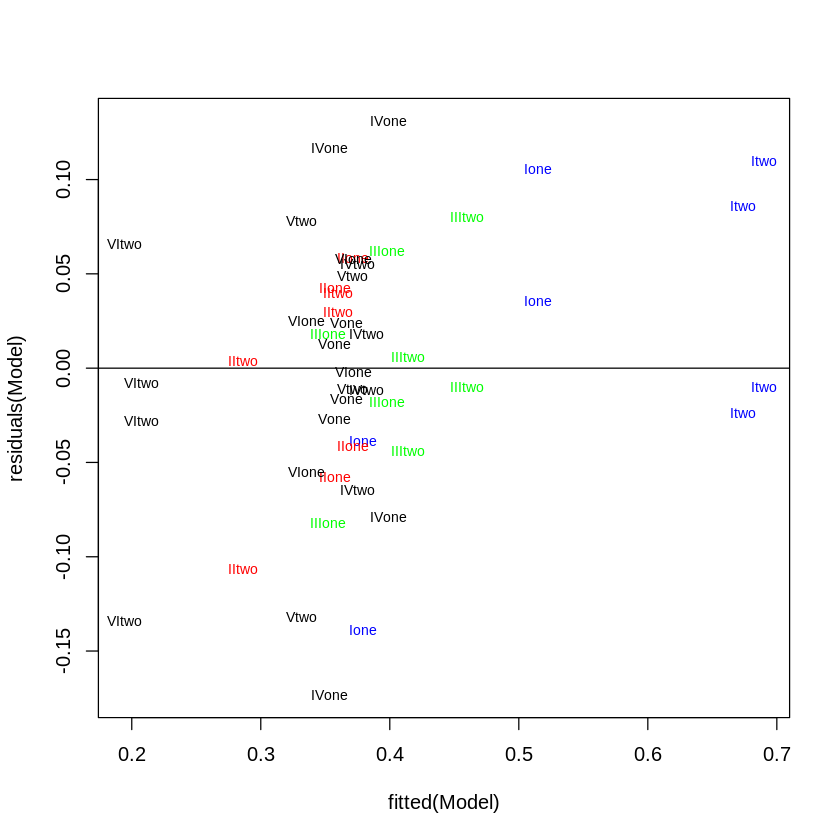

In [40]:
plot(residuals(Model) ~ fitted(Model), type = "n")

text(fitted(Model),
            residuals(Model),
            labels = eggs$Unique,
            col = c("blue", "red", "green", "black")[eggs$Lab],
            cex = 0.7)

abline(h = 0)
abline(h = 3.3, lty = 3)
abline(h = -3.3, lty = 3)

Difficult to say if the data are homogeneously distributed within factors levels due to the 6 observations of lab I especially technician two at far right. But the assumption of homogeneously is less strict for REML method used in lmer().

Are residuals distributed normal.

### Step 17: Normal Q-Q Plot of Residuals

[1] 25  4 48 39

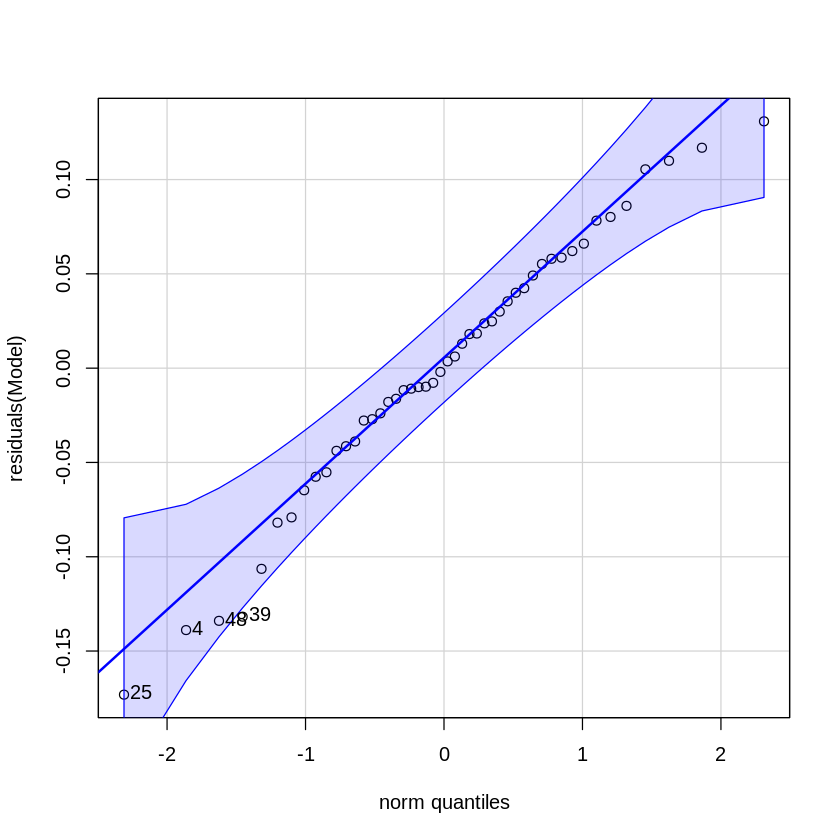

In [42]:
library(car)
qqPlot(residuals(Model), id = list(n = 4))

this also looks fine, the residuals are distributed normal. Are the random factor levels normally distributed?

### Step 18: Q-Q Plot for Random Effects
__Laboratory Random Effects__

[1] 1 6 2 5

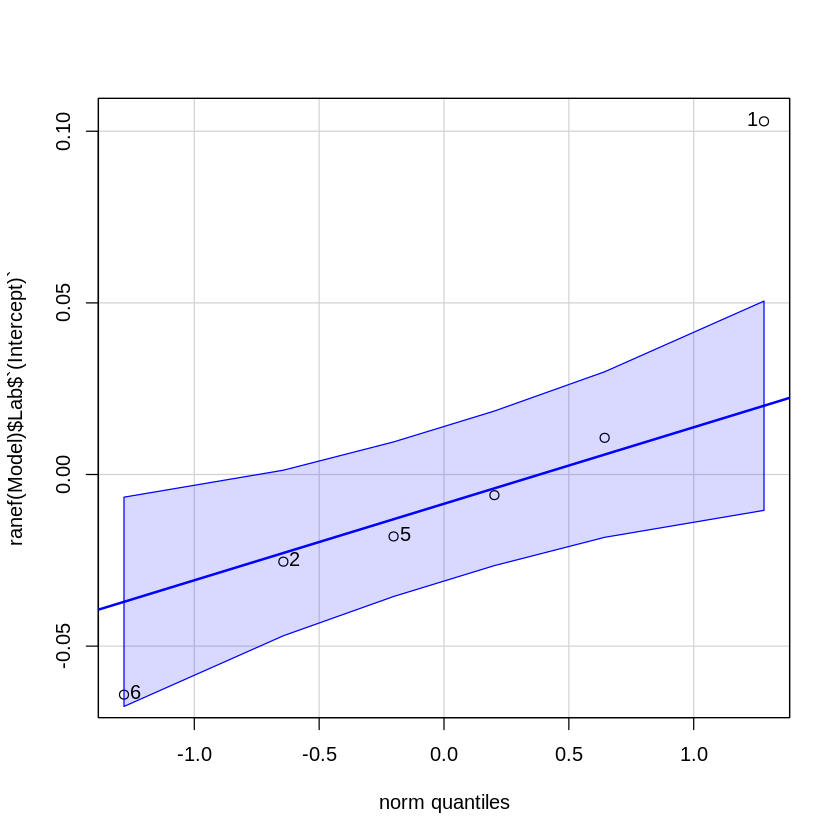

In [44]:
qqPlot(ranef(Model)$Lab$`(Intercept)`, id = list(n = 4))

__Technician Random Effects__

[1]  2 12  1  4

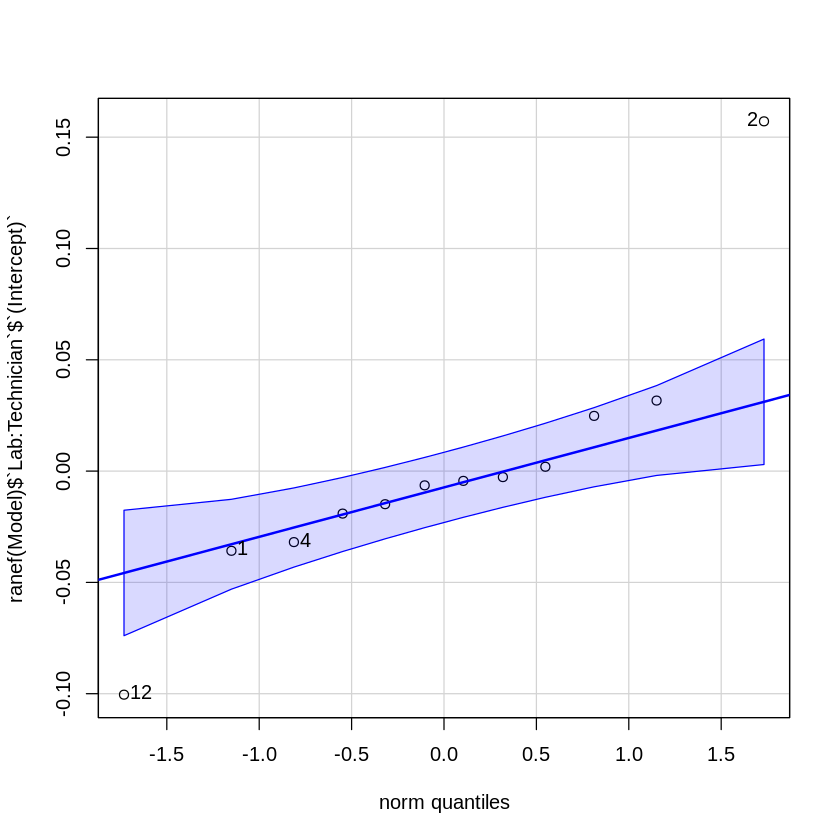

In [46]:
qqPlot(ranef(Model)$`Lab:Technician`$`(Intercept)`, id = list(n = 4))

We see three value more extreme values, in lab row 1 of the dataset and row 2 and 12 for the technicians

### Step 19: Identify Outlying Random Effects

In [48]:
rownames(ranef(Model)$Lab)[1]

[1] "I"

In [49]:
rownames(ranef(Model)$`Lab:Technician`)[c(2, 12)]

[1] "I:two"  "VI:two"

These are the samples from lab I and the technicians working lab I and VI. We can only speculate …

Outliers?

Because we have only random effect, we cannot use the standard function here but let see look at the Random effects.

### Step 20: Dot Plot of Random Effects

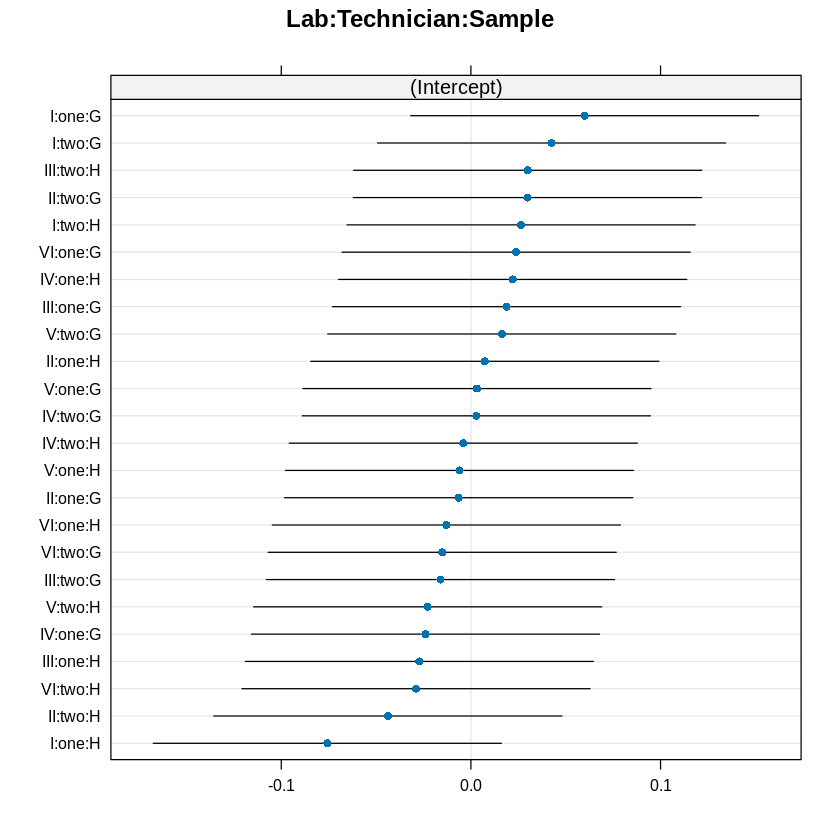

$`Lab:Technician:Sample`

$`Lab:Technician`

$Lab


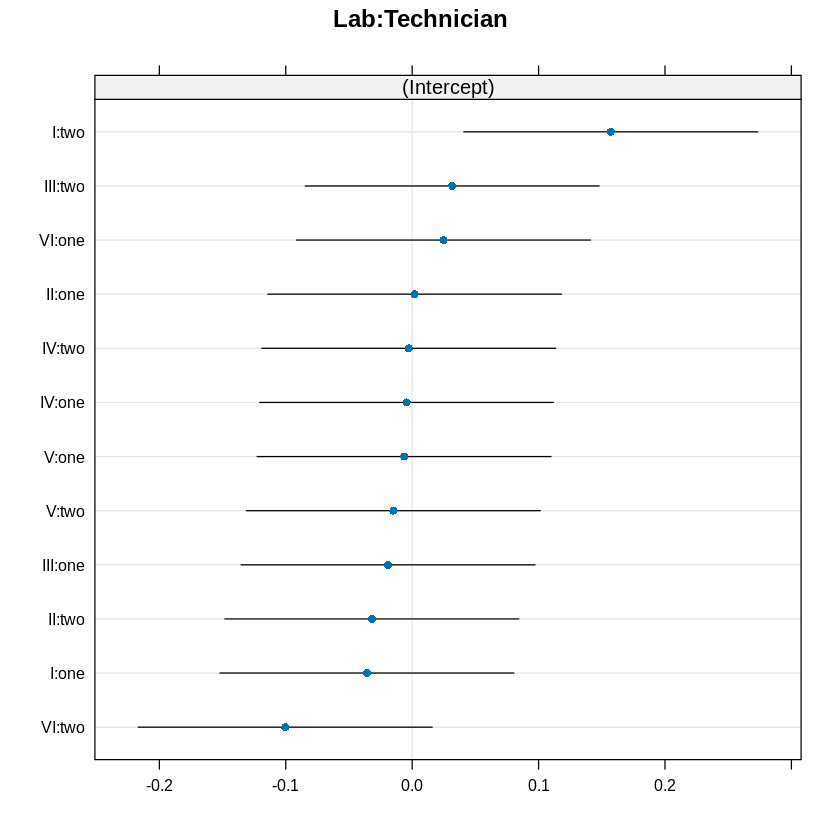

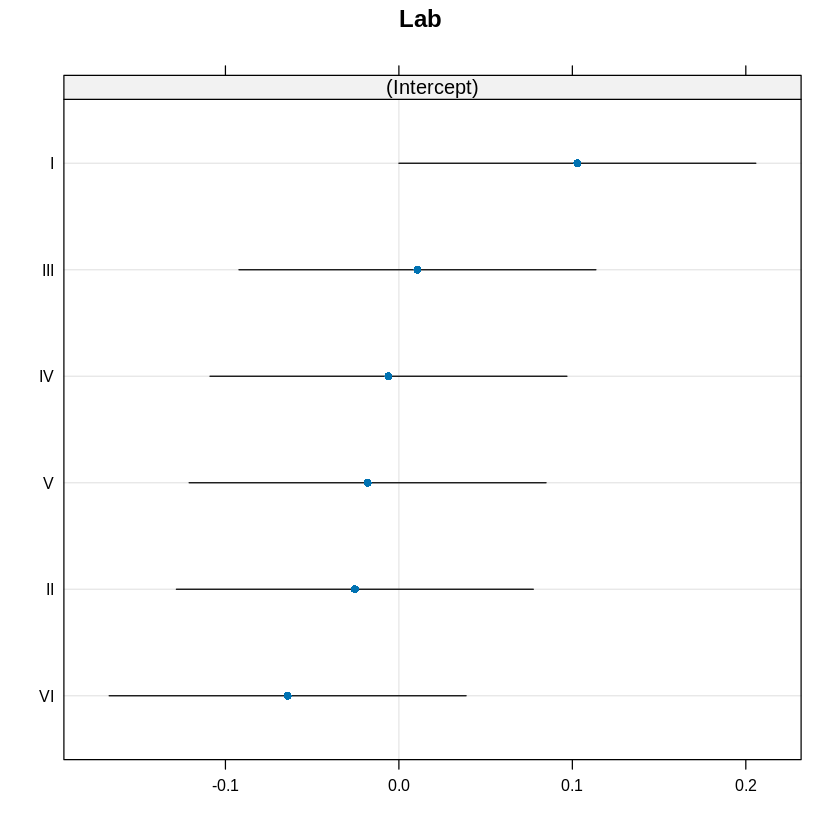

In [50]:
library(lattice)
dotplot( ranef(Model))

The first plot shows the nested samples within the technician and lab. Note that the confidence regions (horizontal lines around the blue points) contain the null hypothesis (dashed vertical line). This might point to a non significant nested effect level. This means that the technicians work very consistently. We see a slight jump of technician 2 in lab 1 and therefore also in Lab one (see also first ggplot above)

In the second plot we see a notable deviation for technician two of lab 1, who on average measured a highest concentrations. The technicians two from lab 6 measured the smallest level of fat.

The third plot shows that lab I measures substantial more fat than the other laboratories.

### Step 21: Shapiro-Wilk Normality Tests
__Technician Effects__

In [51]:
shapiro.test(ranef(Model)$`Lab:Technician`$`(Intercept)`)


	Shapiro-Wilk normality test

data:  ranef(Model)$`Lab:Technician`$`(Intercept)`
W = 0.83501, p-value = 0.02409


__Laboratory Effects__

In [52]:
shapiro.test(ranef(Model)$Lab$`(Intercept)`)


	Shapiro-Wilk normality test

data:  ranef(Model)$Lab$`(Intercept)`
W = 0.88885, p-value = 0.3122


we could take the Technician out but on the other hand its is part of out hypothesis that there is a difference between labs and technicians.

## 7. Statistics:

### Step 22: Model Summary

In [53]:
library(lmerTest)
summary(Model)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
Fat ~ 1 + (1 | Lab) + (1 | Lab:Technician) + (1 | Lab:Technician:Sample)
   Data: eggs

REML criterion at convergence: -64.2

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.04098 -0.46576  0.00927  0.59713  1.54276 

Random effects:
 Groups                Name        Variance Std.Dev.
 Lab:Technician:Sample (Intercept) 0.003065 0.05536 
 Lab:Technician        (Intercept) 0.006980 0.08355 
 Lab                   (Intercept) 0.005920 0.07694 
 Residual                          0.007196 0.08483 
Number of obs: 48, groups:  
Lab:Technician:Sample, 24; Lab:Technician, 12; Lab, 6

Fixed effects:
            Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)  0.38750    0.04296 5.00000   9.019  0.00028 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### Step 23: Test Significance of Random Effects
__Full Model__

In [54]:
Model1 <- lmer(Fat ~ 1 +
    (1 | Lab) +
    (1 | Lab:Technician) +
    (1 | Lab:Technician:Sample),
  REML = FALSE,
  data = eggs)

__Remove Sample Effect__

In [55]:
Model2 <- lmer(Fat ~ 1 +
    (1 | Lab) +
    (1 | Lab:Technician),
  REML = FALSE,
  data = eggs)

__Remove Technician Effect__

In [56]:
Model3 <- lmer(Fat ~ 1 +
    (1 | Lab),
  REML = FALSE,
  data = eggs)

__Likelihood Ratio Tests__

In [58]:
anova(Model1, Model2)

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model2,4,-59.18247,-51.69767,33.59124,-67.18247,NA,NA,NA
Model1,5,-58.78590,-49.42989,34.39295,-68.78590,1.603423,1,0.2054188


In [59]:
anova(Model2, Model3)

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model3,3,-53.27247,-47.65886,29.63623,-59.27247,NA,NA,NA
Model2,4,-59.18247,-51.69767,33.59124,-67.18247,7.910008,1,0.004916206


Model2 is the better model, the verdict is on the labs and the technicians. Well I think that the technicians are actually the hardware as the sample shows us the reproducibility of the technicians.

### Step 24: Best Model

In [60]:
summary(Model2)

Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: Fat ~ 1 + (1 | Lab) + (1 | Lab:Technician)
   Data: eggs

      AIC       BIC    logLik -2*log(L)  df.resid 
    -59.2     -51.7      33.6     -67.2        44 

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.13623 -0.43258  0.06545  0.66331  1.81719 

Random effects:
 Groups         Name        Variance Std.Dev.
 Lab:Technician (Intercept) 0.008002 0.08945 
 Lab            (Intercept) 0.004074 0.06383 
 Residual                   0.009239 0.09612 
Number of obs: 48, groups:  Lab:Technician, 12; Lab, 6

Fixed effects:
            Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)  0.38750    0.03922 6.00000    9.88  6.2e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Note that we still need to use the summary of the whole model because only in that model do we use the correct degree of freedom of the nested model.

We can also look at the confidence interval. Note that using the confint() for and lmer object will use the bootstrap methods, which is not analytic but uses computational resampling methods, will take a bit longer to compute.

### Step 25: Confidence Intervals

In [61]:
confint(Model, method = "profile")

Computing profile confidence intervals ...



,2.5 %,97.5 %
.sig01,0.00000000,0.1151957
.sig02,0.00000000,0.1745312
.sig03,0.00000000,0.1794302
.sigma,0.06550185,0.1158823
(Intercept),0.29651556,0.4784844


### Step 26: Refit Best Model Using REML

In [62]:
Model2 <- lmer(Fat ~ 1 +
    (1 | Lab) +
    (1 | Lab:Technician),
  REML = TRUE,
  data = eggs)

summary(Model2)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Fat ~ 1 + (1 | Lab) + (1 | Lab:Technician)
   Data: eggs

REML criterion at convergence: -62.6

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.17799 -0.42424  0.08043  0.67361  1.77544 

Random effects:
 Groups         Name        Variance Std.Dev.
 Lab:Technician (Intercept) 0.008002 0.08945 
 Lab            (Intercept) 0.005920 0.07694 
 Residual                   0.009239 0.09612 
Number of obs: 48, groups:  Lab:Technician, 12; Lab, 6

Fixed effects:
            Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)  0.38750    0.04296 5.00008   9.019  0.00028 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### Step 27: Confidence Intervals

In [63]:
confint(Model2, method = "profile")

Computing profile confidence intervals ...



,2.5 %,97.5 %
.sig01,0.03819772,0.1772446
.sig02,0.00000000,0.1794295
.sigma,0.07756387,0.1234472
(Intercept),0.29651471,0.4784853


Note first that the the variance of the samples is now added to the technician and residuals. Because the contribution of the technician to the data variance is increased, it has become significant.

## 8. But these extreme values:

### Step 28: Fit Model After Removing Two Observations

In [64]:
Model_Out <- lmer(Fat ~ 1 +
    (1 | Lab) +
    (1 | Lab:Technician) +
    (1 | Lab:Technician:Sample),
  REML = TRUE,
  data = eggs[-c(1, 2), ])

boundary (singular) fit: see help('isSingular')



Interesting but in this case you cannot take out these observations the are only two. It looks like it comes down to a few technicians.

## 9. Simulation:
### Step 29: Simulation from the Mixed Model

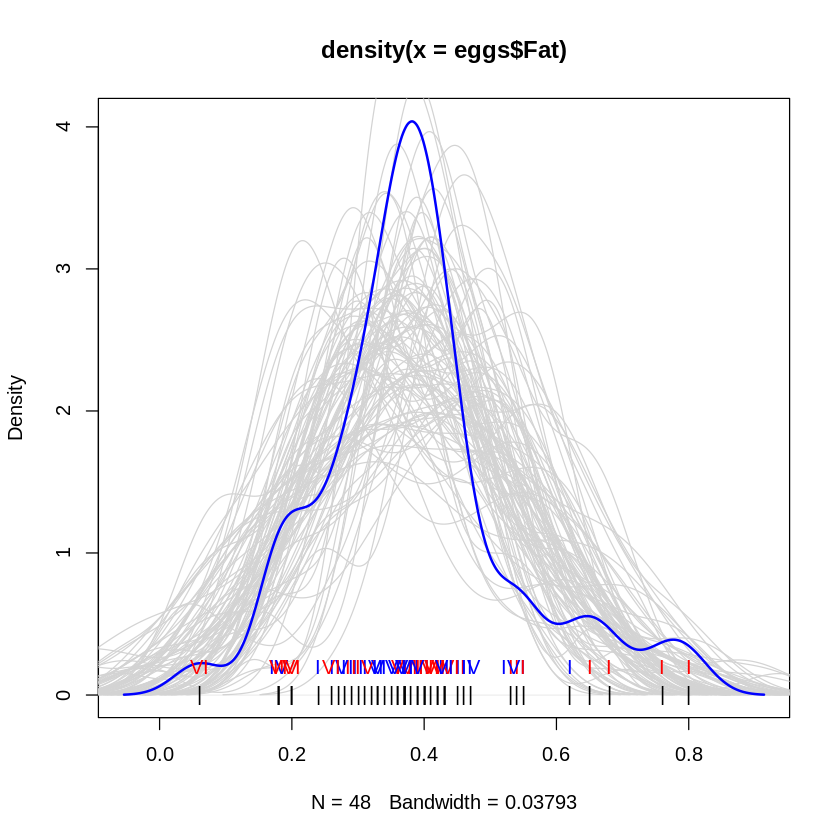

In [69]:
set.seed(265)

plot(density(eggs$Fat), type = "n")
Sim <- simulate(Model, nsim = 100)

# Plot Simulated Distributions
for(i in 1:100){
  lines(density(Sim[[i]]),col = "lightgrey" )}

# Overlay Observed Density
lines(density(eggs$Fat), col = "blue",  lwd = 2)

# Display Original Observations
Nul <- numeric(length(eggs$Fat))
points(eggs$Fat, Nul, pch = "|")
text(eggs$Fat, Nul + 0.2, labels = eggs$Lab, col = c("blue", "red")[eggs$Technician], cex = 1)


Note the large variation in curves, this is possible due to the small sample size

<div class="alert alert-block alert-info" style="margin-top: 20px">
    
### THANK YOU ...!

Ms.MRUNALINI (Data Science Trainer)
